In [1]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#calling internal function
from data_processing import load_fashion_mnist, image_preprocessing, label_encoding
from data_processing import load_synthetic_circle_data, synthetic_data_preprocessing

In [3]:
from k_means import random_init_centroids, euclidean_distance, assign_clusters, mean_image_of_cluster

In [15]:
from k_means_pp import first_centroid 

# Datasets

## Dataset of synthetic circles


In [4]:
X, y = load_synthetic_circle_data()
X_processed = synthetic_data_preprocessing(X)


### Silhuete to chose optimal K number of clusters

## Dataset of fashion MNIST images

In [5]:
X, y = load_fashion_mnist()
X_processed = image_preprocessing(X)
print("Normalised X:", X_processed[:5])
print("Loaded X shape:", X.shape)
print("y:", y[:5])

Normalised X: [[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.07843138 0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
Loaded X shape: (1000, 28, 28)
y: [9 6 4 0 3]


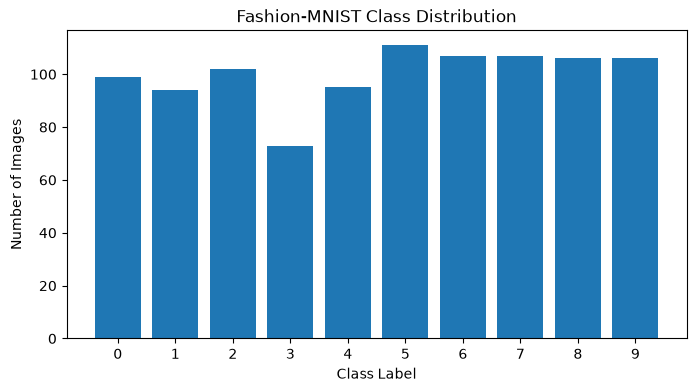

In [6]:
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique, counts)
plt.xticks(unique)
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.title("Fashion-MNIST Class Distribution")
plt.show()

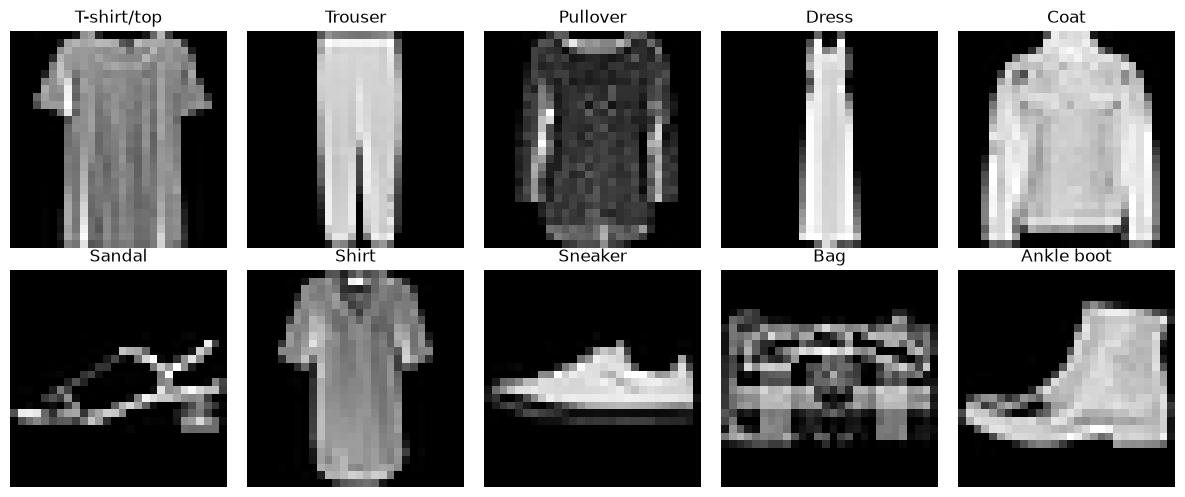

In [7]:
label_names = label_encoding(y)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for class_id in range(10):
    idx = np.where(y == class_id)[0][0]
    axes[class_id].imshow(X[idx], cmap="gray")
    axes[class_id].set_title(label_names[idx])
    axes[class_id].axis("off")

plt.tight_layout()
plt.show()

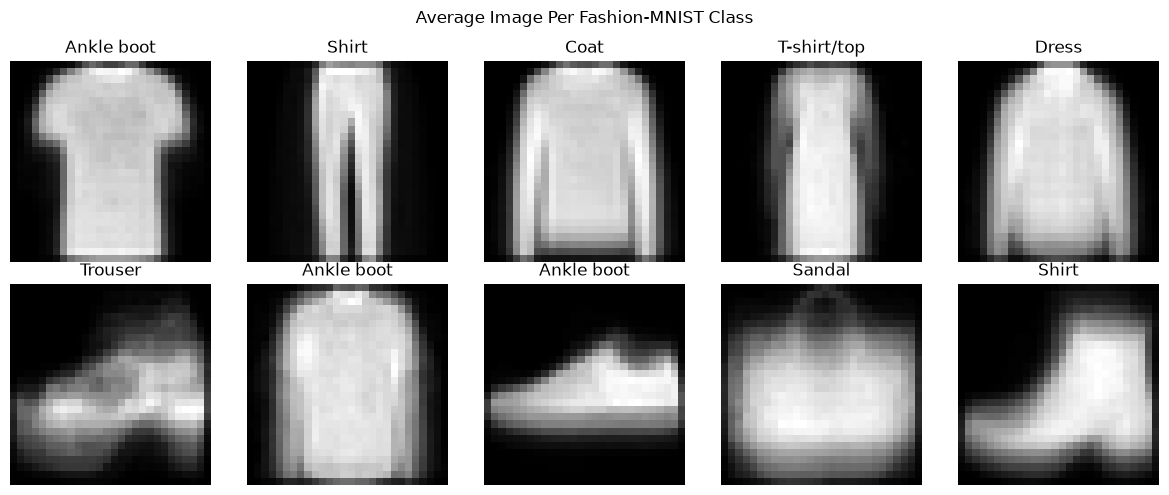

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for class_id in range(10):
    class_images = X[y == class_id]
    mean_image = np.mean(class_images, axis=0)

    axes[class_id].imshow(mean_image, cmap='gray')
    axes[class_id].set_title(label_names[class_id])
    axes[class_id].axis('off')

plt.suptitle("Average Image Per Fashion-MNIST Class")
plt.tight_layout()
plt.show()

# K mean


In [9]:
K = 10
max_iterations = 50
tolerance = 1e-4

In [11]:
centroids = random_init_centroids(X_processed, K)
for iteration in range(max_iterations):
        distances = euclidean_distance(X_processed, centroids,k=K)
        labels = assign_clusters(distances)
        old_centroids = centroids.copy()
        centroids = mean_image_of_cluster(X_processed, labels, K)
        shift = np.linalg.norm(centroids - old_centroids)
        if shift < tolerance:
            print(f"Converged after {iteration + 1} iterations.")
            break



        
    

Converged after 17 iterations.


### Inertia & Variablity

# Kmeans ++

In [16]:
K = 10
max_iterations = 50
tolerance = 1e-4

In [25]:
first_centroid = first_centroid(X_processed)
distances = euclidean_distance(X_processed, first_centroid, k=K)


TypeError: 'numpy.ndarray' object is not callable